In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd

csv_path = "/content/drive/MyDrive/BI_Projects/costumerlens_BI/customer_business_segments.csv"

df = pd.read_csv(csv_path)

df.head()

,customer_id,country,recency,frequency,monetary,avg_order_value,unique_products,total_quantity,customer_lifetime_days,recency_score,frequency_score,monetary_score,rfm_total_score,rfm_score,business_segment
0,18011,United Kingdom,374,1,102.79,102.79,28,71,0,1,1,1,3,111,Hibernating Customers
1,16583,United Kingdom,374,1,233.45,233.45,14,111,0,1,1,1,3,111,Hibernating Customers
2,17643,United Kingdom,374,1,101.55,101.55,8,71,0,1,1,1,3,111,Hibernating Customers
3,14729,United Kingdom,374,1,313.49,313.49,69,197,0,1,2,2,5,122,Hibernating Customers
4,15922,United Kingdom,374,1,369.50,369.50,11,138,0,1,2,2,5,122,Hibernating Customers


In [3]:
df.shape

(4346, 15)

In [4]:
df.columns

Index(['customer_id', 'country', 'recency', 'frequency', 'monetary',
       'avg_order_value', 'unique_products', 'total_quantity',
       'customer_lifetime_days', 'recency_score', 'frequency_score',
       'monetary_score', 'rfm_total_score', 'rfm_score', 'business_segment'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             4346 non-null   int64  
 1   country                 4346 non-null   object 
 2   recency                 4346 non-null   int64  
 3   frequency               4346 non-null   int64  
 4   monetary                4346 non-null   float64
 5   avg_order_value         4346 non-null   float64
 6   unique_products         4346 non-null   int64  
 7   total_quantity          4346 non-null   int64  
 8   customer_lifetime_days  4346 non-null   int64  
 9   recency_score           4346 non-null   int64  
 10  frequency_score         4346 non-null   int64  
 11  monetary_score          4346 non-null   int64  
 12  rfm_total_score         4346 non-null   int64  
 13  rfm_score               4346 non-null   int64  
 14  business_segment        4346 non-null   

In [6]:
df.describe()

,customer_id,recency,frequency,monetary,avg_order_value,unique_products,total_quantity,customer_lifetime_days,recency_score,frequency_score,monetary_score,rfm_total_score,rfm_score
count,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000
mean,15295.109296,93.265992,4.264151,2050.485021,419.282816,61.389554,1189.095260,130.524160,2.999540,2.999540,2.999540,8.998619,332.948919
std,1724.643552,100.115202,7.691263,8981.083042,1794.943708,85.293166,5041.558214,132.204887,1.414539,1.414539,1.414539,3.633877,150.100605
min,12346.000000,1.000000,1.000000,3.750000,3.450000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,3.000000,111.000000
25%,13807.250000,18.000000,1.000000,307.465000,178.905000,16.000000,160.000000,0.000000,2.000000,2.000000,2.000000,6.000000,222.000000
50%,15294.000000,51.000000,2.000000,672.530000,294.270000,35.000000,379.000000,92.000000,3.000000,3.000000,3.000000,9.000000,333.000000
75%,16776.750000,143.000000,5.000000,1661.262500,430.412500,77.000000,990.250000,252.000000,4.000000,4.000000,4.000000,12.000000,454.000000
max,18287.000000,374.000000,209.000000,280206.020000,84236.250000,1787.000000,196915.000000,373.000000,5.000000,5.000000,5.000000,15.000000,555.000000


In [7]:
df["business_segment"].value_counts()

,count
business_segment,
Regular Customers,1365
Hibernating Customers,1078
Champions,948
Loyal Customers,456
New / Promising Customers,310
At Risk High Value,168
Big Spenders,21


In [8]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "unique_products",
    "total_quantity",
    "customer_lifetime_days"
]

X = df[features].copy()

X.head()

,recency,frequency,monetary,avg_order_value,unique_products,total_quantity,customer_lifetime_days
0,374,1,102.79,102.79,28,71,0
1,374,1,233.45,233.45,14,111,0
2,374,1,101.55,101.55,8,71,0
3,374,1,313.49,313.49,69,197,0
4,374,1,369.50,369.50,11,138,0


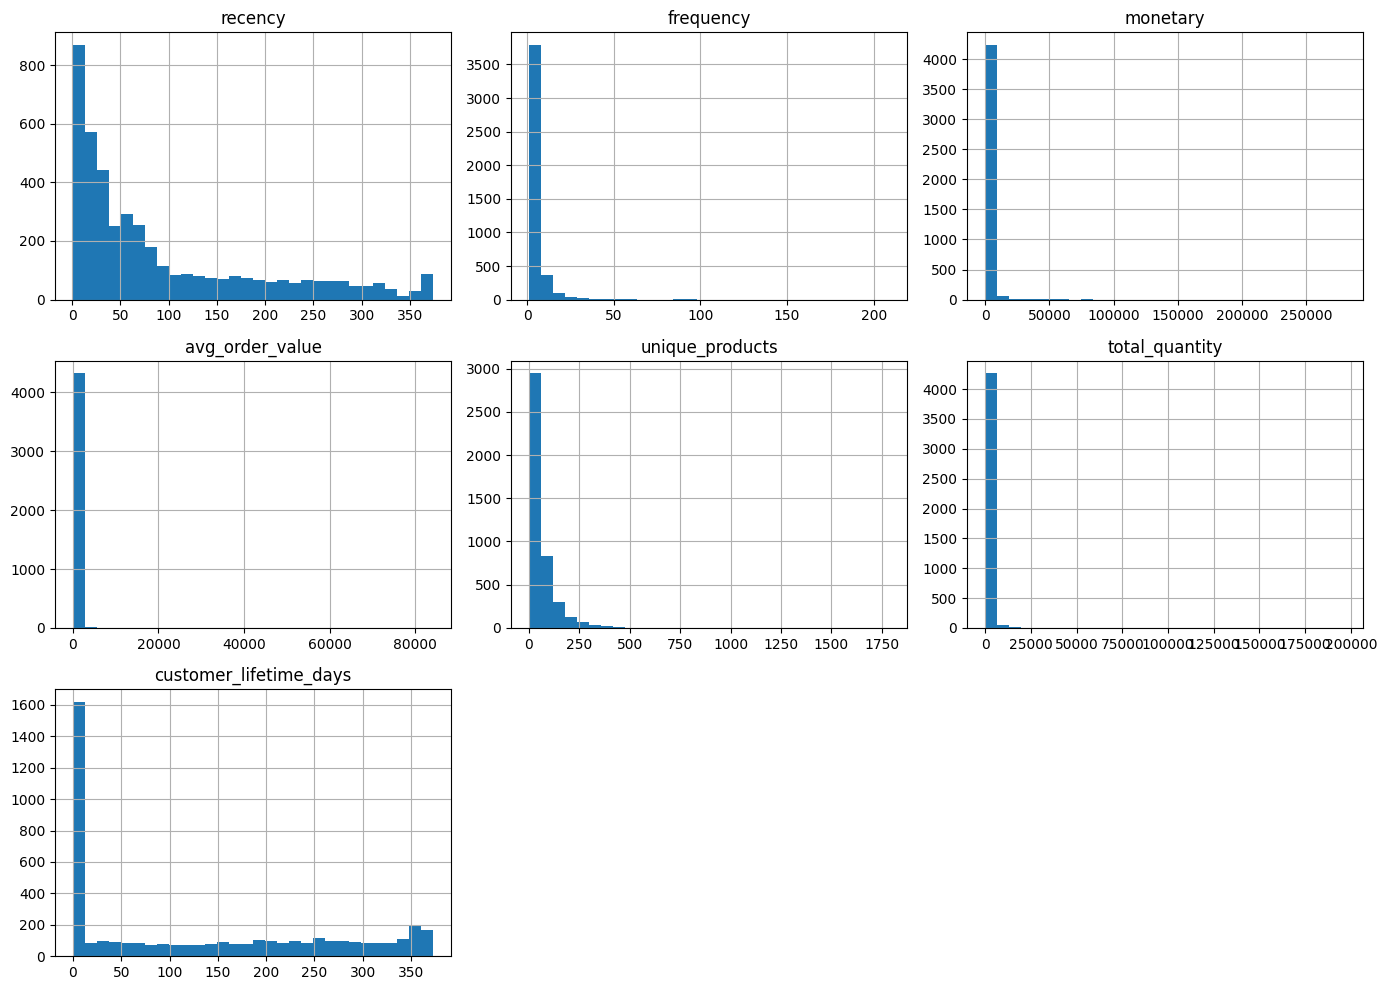

In [9]:
import matplotlib.pyplot as plt

df[features].hist(figsize=(14, 10), bins = 30)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_log = X.copy()

log_features = [
    "frequency",
    "monetary",
    "avg_order_value",
    "unique_products",
    "total_quantity",
    "customer_lifetime_days"
]

X_log[log_features] = np.log1p(X_log[log_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled[:2]

array([[ 2.80443235, -0.95373814, -1.55219447, -1.35539855, -0.16101566,
        -1.24722985, -1.28287514],
       [ 2.80443235, -0.95373814, -0.90354713, -0.26109932, -0.74362842,
        -0.92454589, -1.28287514]])

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

results

,k,inertia,silhouette_score
0,2,17256.752673,0.373674
1,3,13939.736274,0.275370
2,4,11731.991149,0.274234
3,5,10497.953590,0.279122
4,6,9394.692770,0.251350
5,7,8640.308980,0.251137
6,8,8019.044338,0.242533
7,9,7524.947716,0.235996
8,10,7134.898298,0.243162


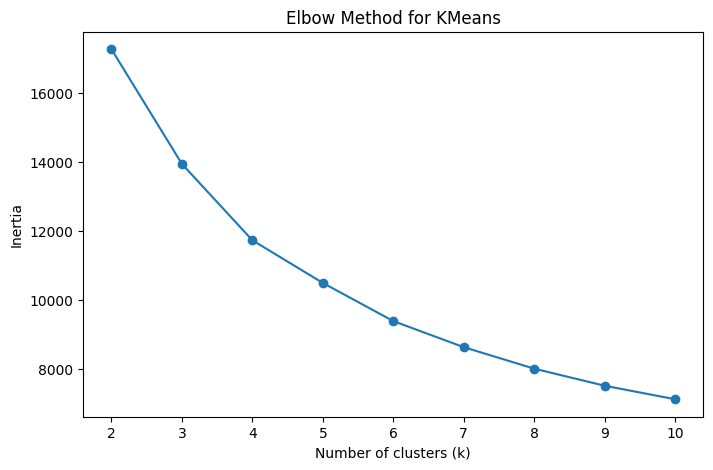

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

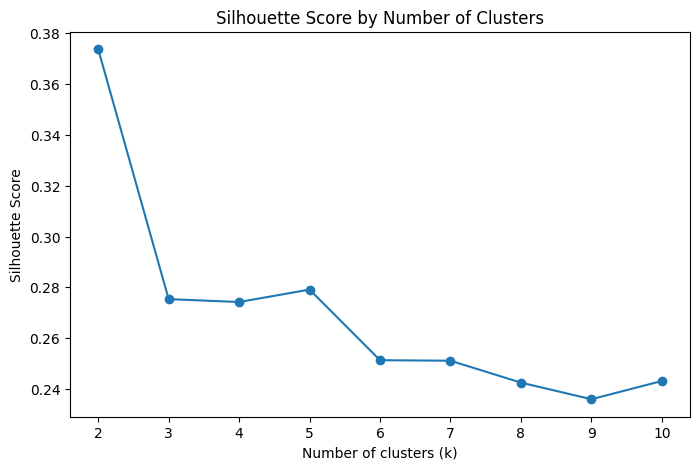

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

k = 2 -> muhtemelen :
* dusuk gelirli pasif musteri
* yuksek gelirli aktif musteri
proje acısından zayıf kalır.   

k = 5 seciyorum cunku 3 ve 4 sınıfa ayırmadan daha yuksek skor verdı musterı davranısına gore 5 e gruplamayı deniyelim.

In [17]:
final_k = 5

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df["ml_cluster"] = kmeans.fit_predict(X_scaled)

df[["customer_id", "business_segment", "ml_cluster"]].head(15)

,customer_id,business_segment,ml_cluster
0,18011,Hibernating Customers,4
1,16583,Hibernating Customers,4
2,17643,Hibernating Customers,4
3,14729,Hibernating Customers,4
4,15922,Hibernating Customers,4
5,16048,Hibernating Customers,4
6,14237,Hibernating Customers,4
7,16274,Hibernating Customers,4
8,15165,Hibernating Customers,4
9,18074,Hibernating Customers,4


In [18]:
df["ml_cluster"].value_counts().sort_index()

,count
ml_cluster,
0,523
1,675
2,1092
3,1494
4,562


In [19]:
cluster_summary = df.groupby("ml_cluster").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_unique_products=("unique_products", "mean"),
    avg_total_quantity=("total_quantity", "mean"),
    avg_lifetime_days=("customer_lifetime_days", "mean")
).round(2)

cluster_summary

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_unique_products,avg_total_quantity,avg_lifetime_days
ml_cluster,,,,,,,,
0,523,145.21,1.30,132.67,110.17,8.76,71.72,18.26
1,675,66.68,1.08,569.05,505.10,30.19,328.54,0.26
2,1092,30.72,10.61,6375.98,739.49,143.36,3684.63,267.66
3,1494,61.26,3.25,845.77,280.90,48.45,508.27,174.68
4,562,283.47,1.23,412.39,349.57,22.96,223.43,7.61


In [20]:
cluster_vs_business = pd.crosstab(
    df["ml_cluster"],
    df["business_segment"],
    normalize="index"
).round(3) * 100

cluster_vs_business

business_segment,At Risk High Value,Big Spenders,Champions,Hibernating Customers,Loyal Customers,New / Promising Customers,Regular Customers
ml_cluster,,,,,,,
0,0.0,0.0,0.0,54.1,0.0,12.0,33.8
1,0.1,2.8,0.0,35.0,0.3,26.2,35.6
2,8.2,0.2,69.4,0.4,15.7,0.2,6.0
3,5.1,0.0,12.7,4.8,18.9,4.6,53.9
4,0.4,0.0,0.0,86.1,0.0,0.0,13.5


In [21]:
pd.crosstab(df["ml_cluster"], df["business_segment"])

business_segment,At Risk High Value,Big Spenders,Champions,Hibernating Customers,Loyal Customers,New / Promising Customers,Regular Customers
ml_cluster,,,,,,,
0,0,0,0,283,0,63,177
1,1,19,0,236,2,177,240
2,89,2,758,4,171,2,66
3,76,0,190,71,283,68,806
4,2,0,0,484,0,0,76


Cluster 0 → Low Value Dormant / Occasional Customers
* customers: 523
* avg_recency: 145.21
* avg_frequency: 1.30
* avg_monetary: 132.67
* avg_lifetime_days: 18.26
```
Bu da düşük harcama + düşük frequency + orta/yüksek recency.
```
---------------------------------------------------------  
Cluster 1 → Recent Low-Frequency Customers  
* customers: 675
* avg_recency: 66.68
* avg_frequency: 1.08
* avg_monetary: 569.05
* avg_lifetime_days: 0.26
```
Bu ilginç. Lifetime neredeyse 0, frequency çok düşük. Yani yeni/tek alışveriş yapmış müşteriler gibi duruyor.
```
----------------------------------------------------------
Cluster 2 → High Value Champions  
* customers: 1092
* avg_recency: 30.72
* avg_frequency: 10.61
* avg_monetary: 6375.98
* avg_unique_products: 143.36
* avg_lifetime_days: 267.66
```
Bu çok net şekilde en güçlü cluster
```
----------------------------------------------------------
Cluster 3 → Regular / Loyal Mid-Value Customers  
* customers: 1494
* avg_recency: 61.26
* avg_frequency: 3.25
* avg_monetary: 845.77
* avg_unique_products: 48.45
* avg_lifetime_days: 174.68
```
orta değerli, tekrar alışveriş yapan, düzenli müşteri grubu
```
----------------------------------------------------------
Cluster 4 → Deep Hibernating Customers  
* customers: 562
* avg_recency: 283.47
* avg_frequency: 1.23
* avg_monetary: 412.39
* avg_lifetime_days: 7.61
```
Bu cluster çok net pasif ve düşük frekanslı müşteri grubu
```

In [23]:
cluster_labels = {
    0: "Low Value Occasional Customers",
    1: "Recent One-Time Buyers",
    2: "High Value Champions",
    3: "Mid-Value Regular Customers",
    4: "Deep Hibernating Customers"
}

df["ml_segment"] = df["ml_cluster"].map(cluster_labels)

df[["customer_id", "business_segment", "ml_cluster", "ml_segment"]].head(2)

,customer_id,business_segment,ml_cluster,ml_segment
0,18011,Hibernating Customers,4,Deep Hibernating Customers
1,16583,Hibernating Customers,4,Deep Hibernating Customers


In [24]:
ml_segment_summary = df.groupby("ml_segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_unique_products=("unique_products", "mean"),
    avg_total_quantity=("total_quantity", "mean"),
    avg_lifetime_days=("customer_lifetime_days", "mean")
).round(2).sort_values("avg_monetary", ascending=False)

ml_segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_unique_products,avg_total_quantity,avg_lifetime_days
ml_segment,,,,,,,,
High Value Champions,1092,30.72,10.61,6375.98,739.49,143.36,3684.63,267.66
Mid-Value Regular Customers,1494,61.26,3.25,845.77,280.90,48.45,508.27,174.68
Recent One-Time Buyers,675,66.68,1.08,569.05,505.10,30.19,328.54,0.26
Deep Hibernating Customers,562,283.47,1.23,412.39,349.57,22.96,223.43,7.61
Low Value Occasional Customers,523,145.21,1.30,132.67,110.17,8.76,71.72,18.26


In [25]:
business_vs_ml = pd.crosstab(
    df["business_segment"],
    df["ml_segment"]
)

business_vs_ml

ml_segment,Deep Hibernating Customers,High Value Champions,Low Value Occasional Customers,Mid-Value Regular Customers,Recent One-Time Buyers
business_segment,,,,,
At Risk High Value,2,89,0,76,1
Big Spenders,0,2,0,0,19
Champions,0,758,0,190,0
Hibernating Customers,484,4,283,71,236
Loyal Customers,0,171,0,283,2
New / Promising Customers,0,2,63,68,177
Regular Customers,76,66,177,806,240


In [26]:
business_vs_ml_pct = pd.crosstab(
    df["business_segment"],
    df["ml_segment"],
    normalize="index"
).round(3) * 100

business_vs_ml_pct

ml_segment,Deep Hibernating Customers,High Value Champions,Low Value Occasional Customers,Mid-Value Regular Customers,Recent One-Time Buyers
business_segment,,,,,
At Risk High Value,1.2,53.0,0.0,45.2,0.6
Big Spenders,0.0,9.5,0.0,0.0,90.5
Champions,0.0,80.0,0.0,20.0,0.0
Hibernating Customers,44.9,0.4,26.3,6.6,21.9
Loyal Customers,0.0,37.5,0.0,62.1,0.4
New / Promising Customers,0.0,0.6,20.3,21.9,57.1
Regular Customers,5.6,4.8,13.0,59.0,17.6


In [28]:
output_path = "/content/drive/MyDrive/BI_Projects/costumerlens_BI/customer_segments_with_ml.csv"

df.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("Shape:", df.shape)

Saved to: /content/drive/MyDrive/BI_Projects/costumerlens_BI/customer_segments_with_ml.csv
Shape: (4346, 17)


In [30]:
from pathlib import Path
import joblib
import json

output_dir = Path("/content/drive/MyDrive/BI_Projects/costumerlens_BI")

joblib.dump(kmeans, output_dir / "kmeans_model.pkl")
joblib.dump(scaler, output_dir / "scaler.pkl")

with open(output_dir / "cluster_labels.json", "w") as f:
    json.dump(cluster_labels, f, indent=4)

with open(output_dir / "features.json", "w") as f:
    json.dump(features, f, indent=4)

print("Artifacts saved to:", output_dir)

Artifacts saved to: /content/drive/MyDrive/BI_Projects/costumerlens_BI
